<a href="https://colab.research.google.com/github/mohammedaslanshas/codomax-ds-internship/blob/main/Day12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Cleaning (from Day 7)
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Organizing (from Day 7)
df = df[["Name", "Age", "Sex", "Pclass", "Survived", "Fare", "Embarked"]]
df = df.rename(columns={"Sex": "Gender", "Pclass": "Ticketclass"})
df["Ticketclass"] = df["Ticketclass"].astype("category")
df["Survived"] = df["Survived"].astype(bool)

# Verify it matches Day 7/8's final state before moving on
print(df.shape)          # should be (891, 7)
print(df.isnull().sum()) # should be all 0
df.info()

(891, 7)
Name           0
Age            0
Gender         0
Ticketclass    0
Survived       0
Fare           0
Embarked       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Name         891 non-null    object  
 1   Age          891 non-null    float64 
 2   Gender       891 non-null    object  
 3   Ticketclass  891 non-null    category
 4   Survived     891 non-null    bool    
 5   Fare         891 non-null    float64 
 6   Embarked     891 non-null    object  
dtypes: bool(1), category(1), float64(2), object(3)
memory usage: 36.8+ KB


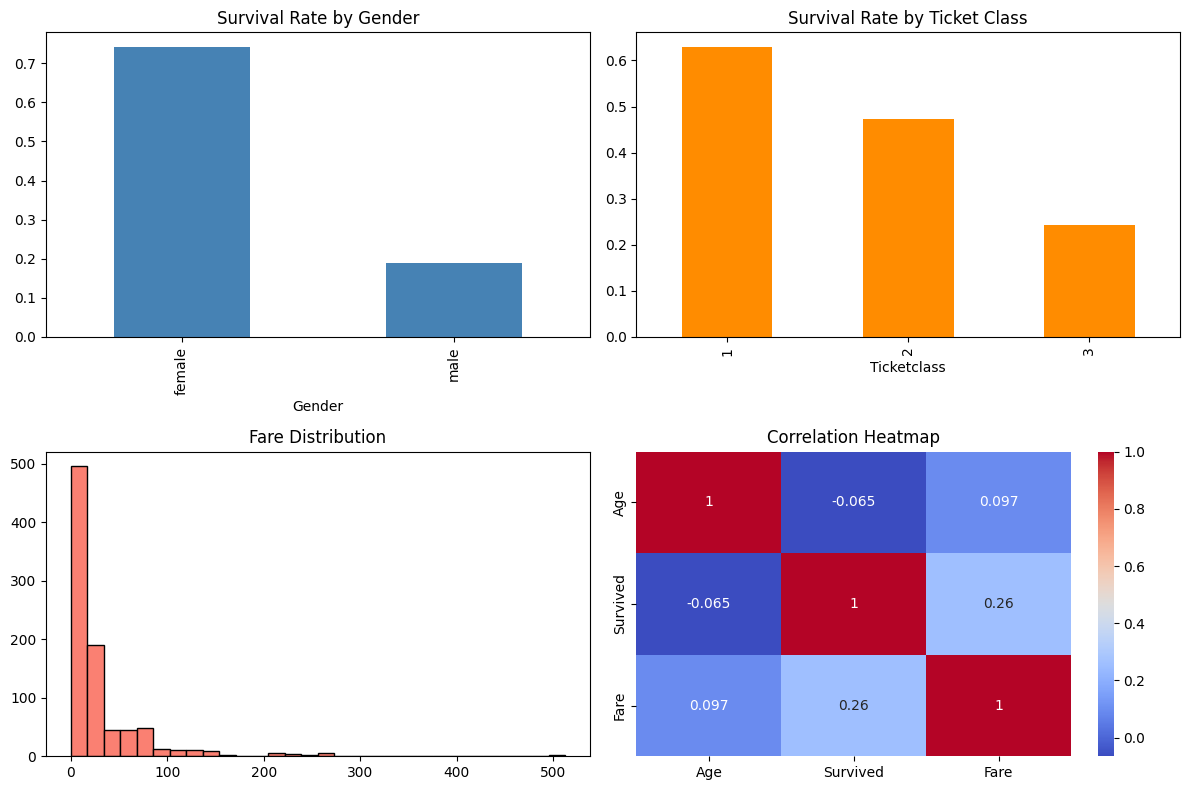

In [2]:

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Survival by Gender
df.groupby("Gender")["Survived"].mean().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Survival Rate by Gender")

# 2. Survival by Ticketclass
df.groupby("Ticketclass", observed=True)["Survived"].mean().plot(kind="bar", ax=axes[0,1], color="darkorange")
axes[0,1].set_title("Survival Rate by Ticket Class")

# 3. Fare distribution
axes[1,0].hist(df["Fare"], bins=30, color="salmon", edgecolor="black")
axes[1,0].set_title("Fare Distribution")

# 4. Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()